In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nelgiriyewithana_mcdonalds_store_reviews_path = kagglehub.dataset_download('nelgiriyewithana/mcdonalds-store-reviews')

print('Data source import complete.')

Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

C:\Users\Enter Store\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Enter Store\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
import pandas as pd
import os

# Kaggle auto-generates this path variable for you
csv_path = os.path.join(
    nelgiriyewithana_mcdonalds_store_reviews_path,
    "McDonald_s_Reviews.csv"
)

df = pd.read_csv(csv_path, encoding='latin-1')  # ✅ add encoding!
print(df.shape)
df.head()

(33396, 10)


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star


In [4]:
df

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star
...,...,...,...,...,...,...,...,...,...,...
33391,33392,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",4 years ago,They treated me very badly.,1 star
33392,33393,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",a year ago,The service is very good,5 stars
33393,33394,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",a year ago,To remove hunger is enough,4 stars
33394,33395,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",5 years ago,"It's good, but lately it has become very expen...",5 stars


In [ ]:
# Variations and symbols for "McDonald's"
"""
mcdonalds_variations = [
    "McDonald's",
    "McDonalds",
    "Mc Donald's",
    "Mc Donalds",
    "McDonalds'",
    "Mcdonald's",
    "mcdonalds",
    "MCDONALDS",
    "McD",
    "McD's",
    "Mickey D's",
    "The Golden Arches",
    "Golden Arches",
    "M"
]

# Example: print all variations
for v in mcdonalds_variations:
    print(v)

# Optional: function to extend a dataset with these variations
def extend_dataset(base_word, variations):
    return list(set([base_word] + variations))

extended_words = extend_dataset("McDonald's", mcdonalds_variations)

print("\nExtended dataset:")
print(extended_words)
"""

In [ ]:
import re
import random

"""mcd_variations = [
    "McDonald's",
    "McDonalds",
    "Mc Donald's",
    "McD",
    "Mickey D's",
    "The Golden Arches",
    "mcdonalds",
    "MCDONALDS",
]"""#replace by "McDonald's"
mcdonalds_variations = [
    "McDonald's",
    "McDonalds",
    "Mc Donald's",
    "Mc Donalds",
    "McDonalds'",
    "Mcdonald's",
    "mcdonalds",
    "MCDONALDS",
    "McD",
    "McD's",
    "Mickey D's",
    "The Golden Arches",
    "Golden Arches",
    "M",
    "mac",
    "mc"
]

pattern = re.compile(r"\bmc\s?donald'?s?\b", re.IGNORECASE)

def replace_mcd(text):
    if pd.isna(text):
        return text
    return pattern.sub(lambda x: random.choice(mcd_variations), text)

# Apply to column
df['review'] = df['review'].apply(replace_mcd)

In [5]:
df['rating'] = df['rating'].str.extract(r'(\d+)')

In [6]:
df_review = df[['review','rating']].copy()

In [7]:
df_grouped_count = df[['store_address', 'rating']].copy()

In [8]:
#group by store_address , rating
grouped_count = df_grouped_count.groupby(['store_address', 'rating']).size().reset_index(name='count')
grouped_count

,store_address,rating,count
0,"1044 US-11, Champlain, NY 12919, United States",1,134
1,"1044 US-11, Champlain, NY 12919, United States",2,67
2,"1044 US-11, Champlain, NY 12919, United States",3,106
3,"1044 US-11, Champlain, NY 12919, United States",4,124
4,"1044 US-11, Champlain, NY 12919, United States",5,189
...,...,...,...
184,"By Mandalay Bay, 3999 S Las Vegas Blvd, Las Ve...",1,320
185,"By Mandalay Bay, 3999 S Las Vegas Blvd, Las Ve...",2,114
186,"By Mandalay Bay, 3999 S Las Vegas Blvd, Las Ve...",3,154
187,"By Mandalay Bay, 3999 S Las Vegas Blvd, Las Ve...",4,152


In [9]:
pivot_table = grouped_count.pivot(index='store_address', columns='rating', values='count').fillna(0)

In [10]:
"""import sys
!{sys.executable} -m pip install seaborn"""

'import sys\n!{sys.executable} -m pip install seaborn'

In [11]:
"""!pip uninstall -y numpy matplotlib seaborn
!pip install numpy==1.26.4
!pip install matplotlib seaborn"""


'!pip uninstall -y numpy matplotlib seaborn\n!pip install numpy==1.26.4\n!pip install matplotlib seaborn'

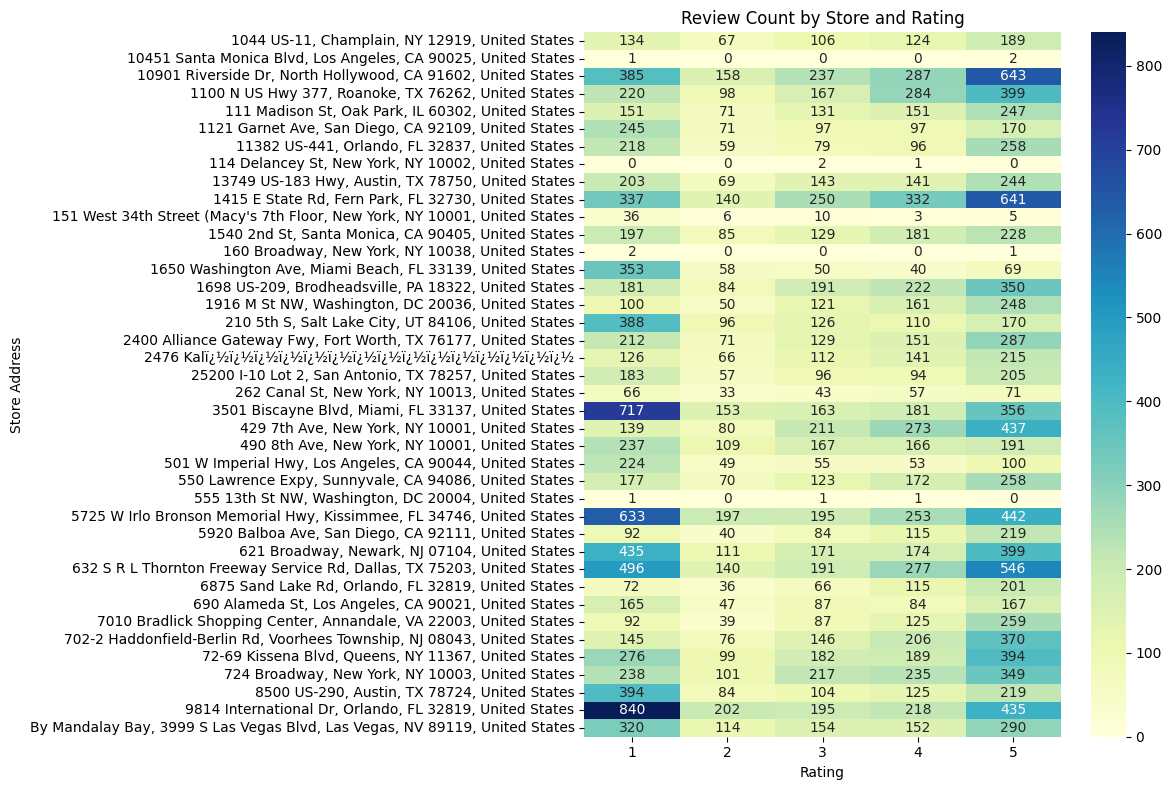

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))  # Adjust size based on number of stores

sns.heatmap(pivot_table, annot=True, fmt='g', cmap='YlGnBu')

plt.title('Review Count by Store and Rating')
plt.xlabel('Rating')
plt.ylabel('Store Address')
plt.tight_layout()
plt.show()

In [13]:
# Make sure columns are integers (if needed)
pivot_table.columns = pivot_table.columns.astype(int)

# Filter stores where 1-star count > 5-star count
filtered_stores = pivot_table[pivot_table[1] > pivot_table[5]]

# Get only the store addresses
store_addresses = filtered_stores.index.tolist()

print("Stores where 1-star reviews are greater than 5-star reviews:")
print(store_addresses)

Stores where 1-star reviews are greater than 5-star reviews:
['1121 Garnet Ave, San Diego, CA 92109, United States', "151 West 34th Street (Macy's 7th Floor, New York, NY 10001, United States", '160 Broadway, New York, NY 10038, United States', '1650 Washington Ave, Miami Beach, FL 33139, United States', '210 5th S, Salt Lake City, UT 84106, United States', '3501 Biscayne Blvd, Miami, FL 33137, United States', '490 8th Ave, New York, NY 10001, United States', '501 W Imperial Hwy, Los Angeles, CA 90044, United States', '555 13th St NW, Washington, DC 20004, United States', '5725 W Irlo Bronson Memorial Hwy, Kissimmee, FL 34746, United States', '621 Broadway, Newark, NJ 07104, United States', '8500 US-290, Austin, TX 78724, United States', '9814 International Dr, Orlando, FL 32819, United States', 'By Mandalay Bay, 3999 S Las Vegas Blvd, Las Vegas, NV 89119, United States']


In [14]:
filtered_stores

rating,1,2,3,4,5
store_address,,,,,
"1121 Garnet Ave, San Diego, CA 92109, United States",245.0,71.0,97.0,97.0,170.0
"151 West 34th Street (Macy's 7th Floor, New York, NY 10001, United States",36.0,6.0,10.0,3.0,5.0
"160 Broadway, New York, NY 10038, United States",2.0,0.0,0.0,0.0,1.0
"1650 Washington Ave, Miami Beach, FL 33139, United States",353.0,58.0,50.0,40.0,69.0
"210 5th S, Salt Lake City, UT 84106, United States",388.0,96.0,126.0,110.0,170.0
"3501 Biscayne Blvd, Miami, FL 33137, United States",717.0,153.0,163.0,181.0,356.0
"490 8th Ave, New York, NY 10001, United States",237.0,109.0,167.0,166.0,191.0
"501 W Imperial Hwy, Los Angeles, CA 90044, United States",224.0,49.0,55.0,53.0,100.0
"555 13th St NW, Washington, DC 20004, United States",1.0,0.0,1.0,1.0,0.0


<Axes: xlabel='rating', ylabel='store_address'>

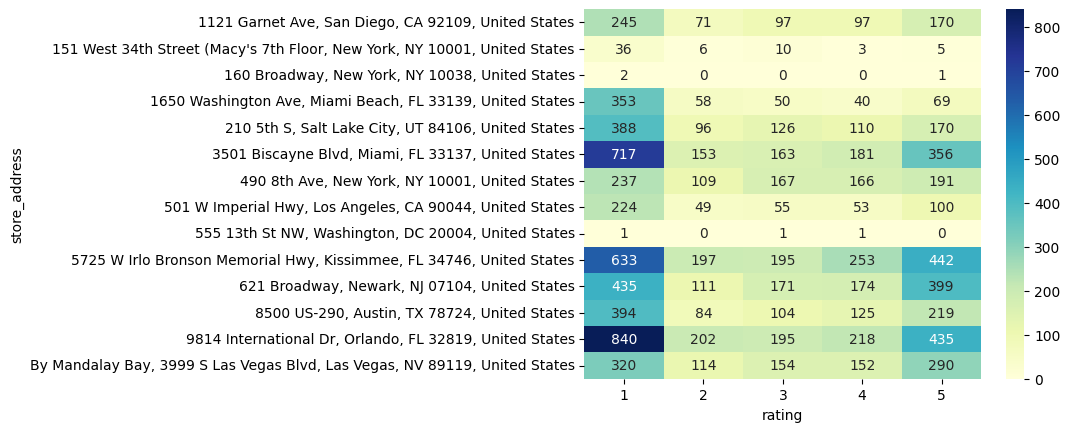

In [15]:
import seaborn as sns

sns.heatmap(filtered_stores, annot=True, fmt='g', cmap='YlGnBu')

In [ ]:
# Make sure columns are integers (if needed)
pivot_table.columns = pivot_table.columns.astype(int)

# Filter stores where 1-star count > 5-star count
perfect_stores = pivot_table[pivot_table[1] < pivot_table[5]]

# Get only the store addresses
store_addresses = perfect_stores.index.tolist()

print("Stores where 5-star reviews are greater than 1-star reviews:")
print(store_addresses)

In [ ]:
import seaborn as sns

sns.heatmap(perfect_stores, annot=True, fmt='g', cmap='YlGnBu')

In [16]:
df

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1
...,...,...,...,...,...,...,...,...,...,...
33391,33392,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",4 years ago,They treated me very badly.,1
33392,33393,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",a year ago,The service is very good,5
33393,33394,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",a year ago,To remove hunger is enough,4
33394,33395,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",5 years ago,"It's good, but lately it has become very expen...",5


In [17]:
# Create the 'total_reviews' column
pivot_table['total_reviews'] = pivot_table.sum(axis=1)

In [18]:
pivot_table = pivot_table.fillna(0)

pivot_table['bad_gap'] = pivot_table[1] - pivot_table[5]
pivot_table['bad_ratio'] = pivot_table[1] / (pivot_table[5] + 1)

worst_stores = pivot_table[pivot_table['bad_gap'] > 0] \
                .sort_values(by='bad_gap', ascending=False)

worst_stores[['bad_gap', 'bad_ratio']].head(10)

pivot_table['total_reviews'] = pivot_table.sum(axis=1)

worst_stores = worst_stores[worst_stores['total_reviews'] > 30]

In [19]:
df

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1
...,...,...,...,...,...,...,...,...,...,...
33391,33392,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",4 years ago,They treated me very badly.,1
33392,33393,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",a year ago,The service is very good,5
33393,33394,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",a year ago,To remove hunger is enough,4
33394,33395,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",5 years ago,"It's good, but lately it has become very expen...",5


In [20]:
pivot_table

rating,1,2,3,4,5,total_reviews,bad_gap,bad_ratio
store_address,,,,,,,,
"1044 US-11, Champlain, NY 12919, United States",134.0,67.0,106.0,124.0,189.0,1185.705263,-55.0,0.705263
"10451 Santa Monica Blvd, Los Angeles, CA 90025, United States",1.0,0.0,0.0,0.0,2.0,5.333333,-1.0,0.333333
"10901 Riverside Dr, North Hollywood, CA 91602, United States",385.0,158.0,237.0,287.0,643.0,3162.597826,-258.0,0.597826
"1100 N US Hwy 377, Roanoke, TX 76262, United States",220.0,98.0,167.0,284.0,399.0,2157.550000,-179.0,0.550000
"111 Madison St, Oak Park, IL 60302, United States",151.0,71.0,131.0,151.0,247.0,1406.608871,-96.0,0.608871
"1121 Garnet Ave, San Diego, CA 92109, United States",245.0,71.0,97.0,97.0,170.0,1436.432749,75.0,1.432749
"11382 US-441, Orlando, FL 32837, United States",218.0,59.0,79.0,96.0,258.0,1380.841699,-40.0,0.841699
"114 Delancey St, New York, NY 10002, United States",0.0,0.0,2.0,1.0,0.0,6.000000,0.0,0.000000
"13749 US-183 Hwy, Austin, TX 78750, United States",203.0,69.0,143.0,141.0,244.0,1559.828571,-41.0,0.828571


In [21]:
df

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1
...,...,...,...,...,...,...,...,...,...,...
33391,33392,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",4 years ago,They treated me very badly.,1
33392,33393,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",a year ago,The service is very good,5
33393,33394,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",a year ago,To remove hunger is enough,4
33394,33395,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",5 years ago,"It's good, but lately it has become very expen...",5


In [22]:
pivot_table['total_reviews'] == ( pivot_table[1] + pivot_table[2] + pivot_table[3] + pivot_table[4] + pivot_table[5])

store_address
1044 US-11, Champlain, NY 12919, United States                                False
10451 Santa Monica Blvd, Los Angeles, CA 90025, United States                 False
10901 Riverside Dr, North Hollywood, CA 91602, United States                  False
1100 N US Hwy 377, Roanoke, TX 76262, United States                           False
111 Madison St, Oak Park, IL 60302, United States                             False
1121 Garnet Ave, San Diego, CA 92109, United States                           False
11382 US-441, Orlando, FL 32837, United States                                False
114 Delancey St, New York, NY 10002, United States                            False
13749 US-183 Hwy, Austin, TX 78750, United States                             False
1415 E State Rd, Fern Park, FL 32730, United States                           False
151 West 34th Street (Macy's 7th Floor, New York, NY 10001, United States     False
1540 2nd St, Santa Monica, CA 90405, United States            

In [23]:
"""pivot_table['avg_rating'] = (
    pivot_table[1]*1 +
    pivot_table[2]*2 +
    pivot_table[3]*3 +
    pivot_table[4]*4 +
    pivot_table[5]*5
) / pivot_table['total_reviews']"""

pivot_table['mean_rating'] = (
    pivot_table[1]*1 +
    pivot_table[2]*2 +
    pivot_table[3]*3 +
    pivot_table[4]*4 +
    pivot_table[5]*5
) / (
    pivot_table[1] +
    pivot_table[2] +
    pivot_table[3] +
    pivot_table[4] +
    pivot_table[5]
)

#worst_stores[['mean_rating']].sort_values(by='mean_rating').head(10)
#pivot_table.sort_values(by='mean_rating').head(10)[['mean_rating']]
pivot_table.sort_values(by='mean_rating')[['mean_rating']]

rating,mean_rating
store_address,
"151 West 34th Street (Macy's 7th Floor, New York, NY 10001, United States",1.916667
"1650 Washington Ave, Miami Beach, FL 33139, United States",1.971930
"160 Broadway, New York, NY 10038, United States",2.333333
"501 W Imperial Hwy, Los Angeles, CA 90044, United States",2.492723
"210 5th S, Salt Lake City, UT 84106, United States",2.525843
"3501 Biscayne Blvd, Miami, FL 33137, United States",2.557962
"9814 International Dr, Orlando, FL 32819, United States",2.579894
"8500 US-290, Austin, TX 78724, United States",2.666307
"555 13th St NW, Washington, DC 20004, United States",2.666667


In [24]:
"""
best_stores = pivot_table[pivot_table[5] > pivot_table[1]]
best_stores.sort_values(by='avg_rating')"""

"\nbest_stores = pivot_table[pivot_table[5] > pivot_table[1]]\nbest_stores.sort_values(by='avg_rating')"

In [25]:
#lineplot -> store_address , review_time , rating
#subplot by : store_address , x-axis: review_time , y-axis: rating

In [26]:
df

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1
...,...,...,...,...,...,...,...,...,...,...
33391,33392,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",4 years ago,They treated me very badly.,1
33392,33393,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",a year ago,The service is very good,5
33393,33394,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",a year ago,To remove hunger is enough,4
33394,33395,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",5 years ago,"It's good, but lately it has become very expen...",5


In [27]:
#df['review_time'] = pd.to_datetime(df['review_time'])
df = df.sort_values(['store_address', 'review_time'])

In [28]:
df['rating'] = pd.to_numeric(df['rating'])

In [29]:
df_timeline_store = df[['store_address', 'rating' , 'rating_count','review_time']].copy()
df_timeline_store = df_timeline_store.sort_values('review_time')

In [30]:
"""
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df_timeline_store,
    col="store_address",
    col_wrap=2,          # 4 plots per row
    height=3,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="review_time",
    y="rating"
)

g.set_axis_labels("Review Time", "Rating")
g.set_titles("{col_name}")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()"""

'\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\ng = sns.FacetGrid(\n    df_timeline_store,\n    col="store_address",\n    col_wrap=2,          # 4 plots per row\n    height=3,\n    sharey=True\n)\n\ng.map_dataframe(\n    sns.lineplot,\n    x="review_time",\n    y="rating"\n)\n\ng.set_axis_labels("Review Time", "Rating")\ng.set_titles("{col_name}")\n\nplt.xticks(rotation=45)\nplt.tight_layout()\nplt.show()'

In [31]:
"""
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df_timeline_store,
    col="store_address",
    col_wrap=2,
    height=3,
    sharey=True,
    sharex=False   # 🔥 IMPORTANT
)

g.map_dataframe(
    sns.lineplot,
    x="review_time",
    y="rating",
    marker="o",
    estimator=None
)

g.set_axis_labels("Review Time", "Rating")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()"""

'\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\ng = sns.FacetGrid(\n    df_timeline_store,\n    col="store_address",\n    col_wrap=2,\n    height=3,\n    sharey=True,\n    sharex=False   # 🔥 IMPORTANT\n)\n\ng.map_dataframe(\n    sns.lineplot,\n    x="review_time",\n    y="rating",\n    marker="o",\n    estimator=None\n)\n\ng.set_axis_labels("Review Time", "Rating")\ng.set_titles("{col_name}")\n\nfor ax in g.axes.flatten():\n    ax.tick_params(axis=\'x\', rotation=45)\n\nplt.tight_layout()\nplt.show()'

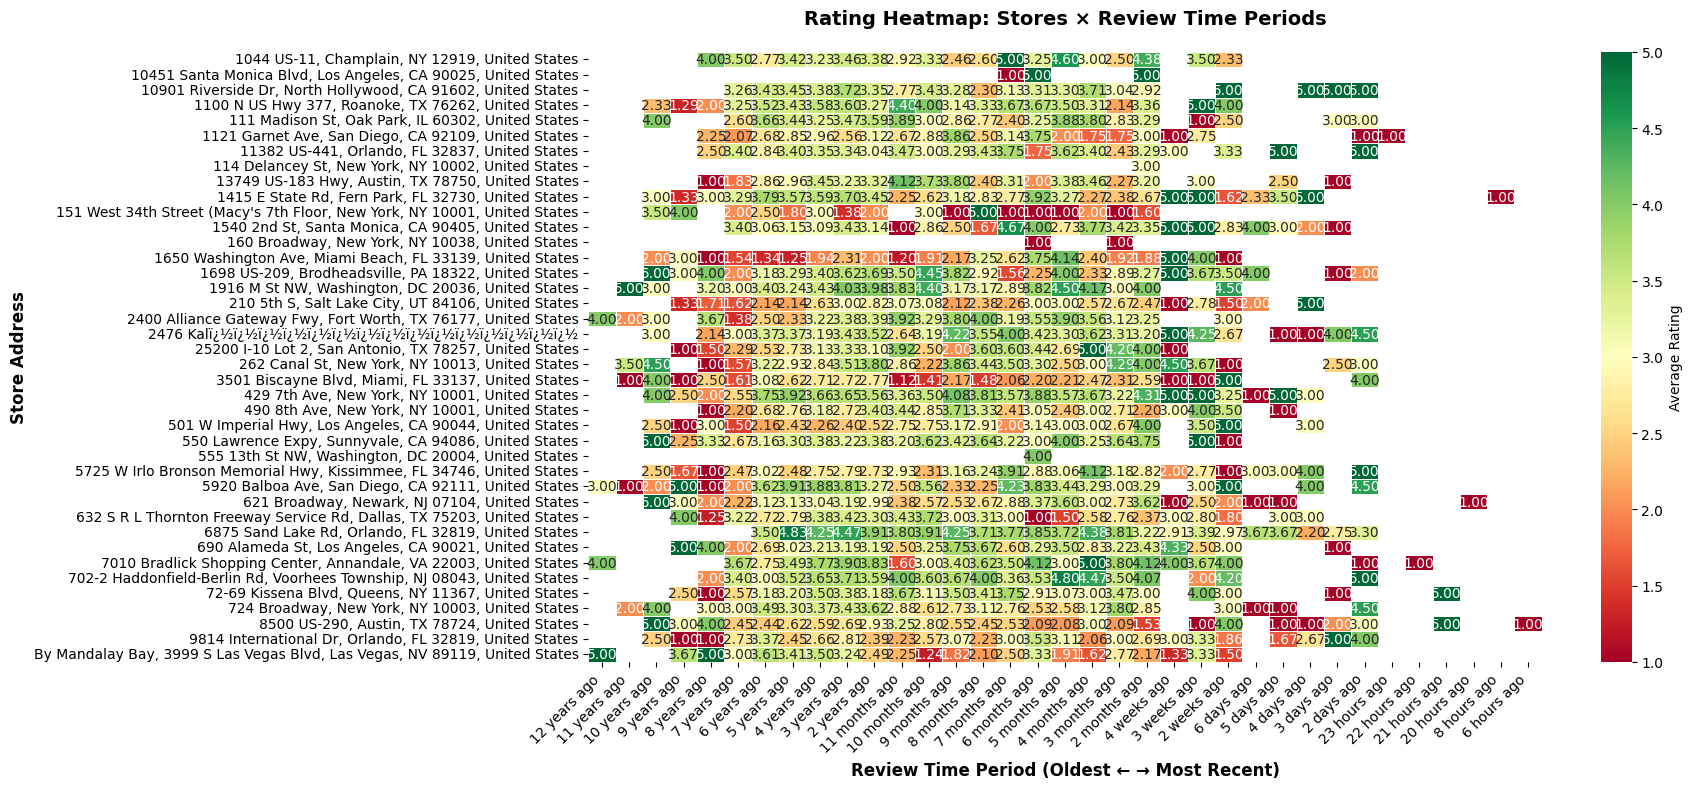

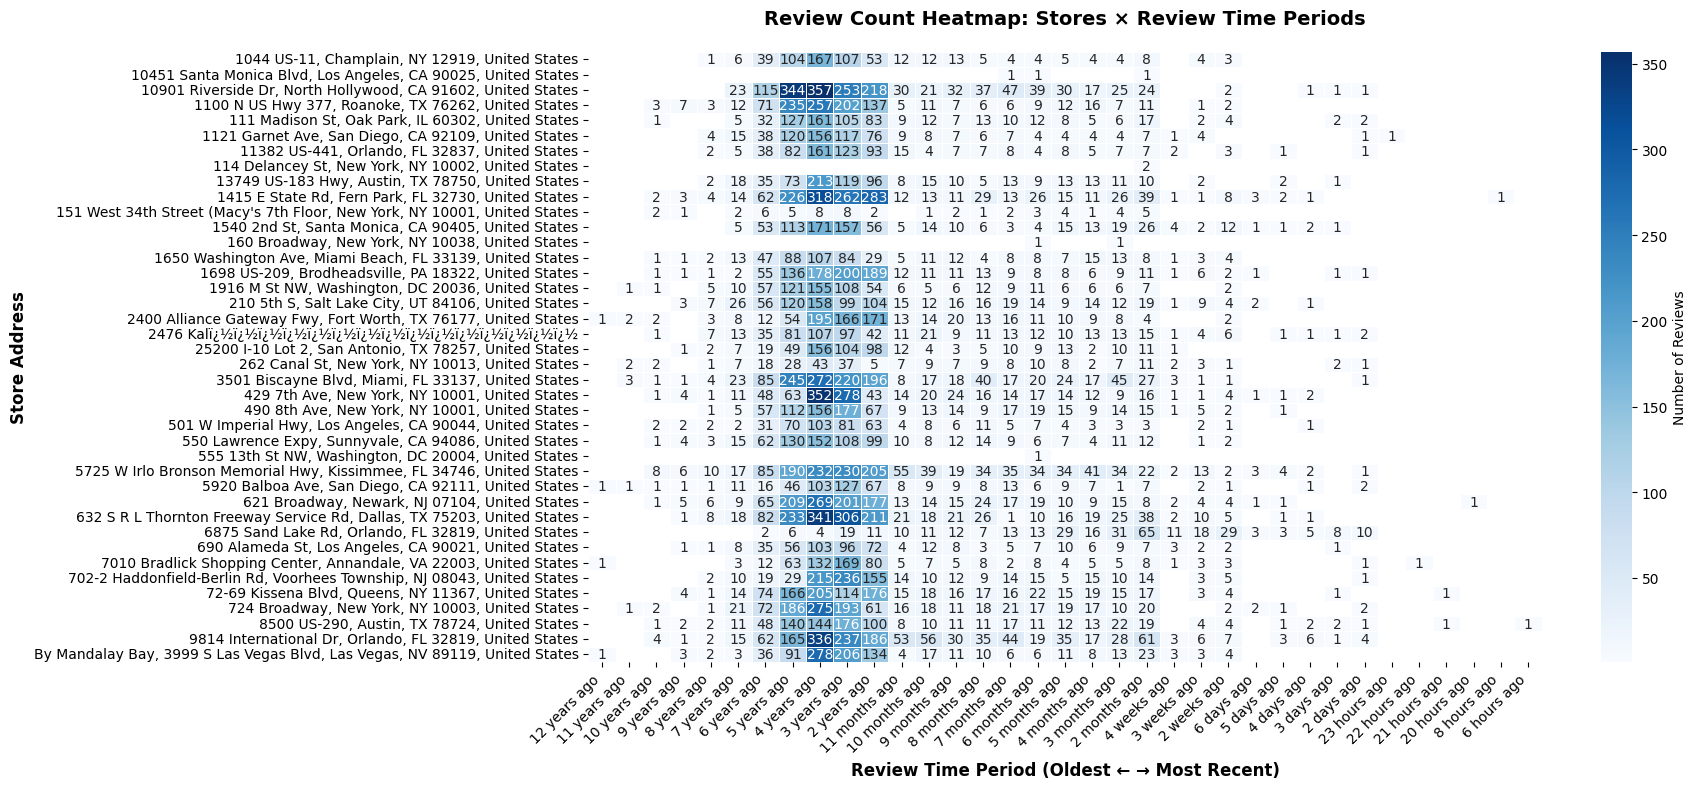

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import re

# ============================================================================
# CORRECT AUTO-SORT: OLDEST TO NEWEST (Furthest past to most recent)
# Years (1,2,3...) → Months (1,2,3...) → Weeks (1,2,3...) → Days (1,2,3...) → Hours (1,2,3...)
# ============================================================================

def get_time_sort_order(time_list):

    def extract_number(time_str):
        """Extract the number from time string (e.g., '2 weeks ago' -> 2)"""
        match = re.match(r'(\d+)', time_str)
        return int(match.group(1)) if match else 0

    # Separate by type and sort each type numerically (DESCENDING = largest to smallest within each category)
    years = sorted(
        [t for t in time_list if re.search(r'\d+\s*year', t.lower())],
        key=extract_number,
        reverse=True  # 3 years, 2 years, 1 year... (descending)
    )

    months = sorted(
        [t for t in time_list if re.search(r'\d+\s*month', t.lower())],
        key=extract_number,
        reverse=True  # 12 months, 11 months, 10 months... 1 month (descending)
    )

    weeks = sorted(
        [t for t in time_list if re.search(r'\d+\s*week', t.lower())],
        key=extract_number,
        reverse=True  # 52 weeks, 51 weeks... 1 week (descending)
    )

    days = sorted(
        [t for t in time_list if re.search(r'\d+\s*day', t.lower())],
        key=extract_number,
        reverse=True  # descending
    )

    hours = sorted(
        [t for t in time_list if re.search(r'\d+\s*hour', t.lower())],
        key=extract_number,
        reverse=True  # descending
    )

    # Concatenate: YEARS + MONTHS + WEEKS + DAYS + HOURS
    # This creates: oldest year → newest year → oldest month → newest month → ... → newest hour
    return years + months + weeks + days + hours

# Get correctly sorted time order
time_order = get_time_sort_order(df['review_time'].unique().tolist())
#print(f"Correctly sorted time periods (oldest to most recent):\n{time_order}\n")

pivot_table = df.pivot_table(
    index='store_address',
    columns='review_time',
    values='rating',
    aggfunc='mean'
)

# Reorder columns by correctly sorted time periods
pivot_table = pivot_table[[col for col in time_order if col in pivot_table.columns]]

fig, ax = plt.subplots(figsize=(18, 8))

sns.heatmap(
    pivot_table,
    annot=True,           # Show values in cells
    fmt='.2f',            # Format to 2 decimal places
    cmap='RdYlGn',        # Red-Yellow-Green colormap (red=low, green=high)
    cbar_kws={'label': 'Average Rating'},
    linewidths=0.5,       # Lines between cells
    vmin=1,               # Min value for color scale
    vmax=5,               # Max value for color scale
    ax=ax
)

plt.title('Rating Heatmap: Stores × Review Time Periods',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Review Time Period (Oldest ← → Most Recent)', fontsize=12, fontweight='bold')
plt.ylabel('Store Address', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

review_counts = df.pivot_table(
    index='store_address',
    columns='review_time',
    values='rating',
    aggfunc='count'
)

review_counts = review_counts[[col for col in time_order if col in review_counts.columns]]

fig, ax = plt.subplots(figsize=(18, 8))

sns.heatmap(
    review_counts,
    annot=True,
    fmt='g',
    cmap='Blues',
    cbar_kws={'label': 'Number of Reviews'},
    linewidths=0.5,
    ax=ax
)

plt.title('Review Count Heatmap: Stores × Review Time Periods',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Review Time Period (Oldest ← → Most Recent)', fontsize=12, fontweight='bold')
plt.ylabel('Store Address', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
df_review

,review,rating
0,Why does it look like someone spit on my food?...,1
1,It'd McDonalds. It is what it is as far as the...,4
2,Made a mobile order got to the speaker and che...,1
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5
4,"I repeat my order 3 times in the drive thru, a...",1
...,...,...
33391,They treated me very badly.,1
33392,The service is very good,5
33393,To remove hunger is enough,4
33394,"It's good, but lately it has become very expen...",5


In [34]:
df

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
11906,11907,McDonald's,Fast food restaurant,"1044 US-11, Champlain, NY 12919, United States",44.981410,-73.459820,"1,306",10 months ago,I stop at this McDonald's like once a week or ...,3
11937,11938,McDonald's,Fast food restaurant,"1044 US-11, Champlain, NY 12919, United States",44.981410,-73.459820,"1,306",10 months ago,A complete joke I told them I wanted a medium ...,1
11960,11961,McDonald's,Fast food restaurant,"1044 US-11, Champlain, NY 12919, United States",44.981410,-73.459820,"1,306",10 months ago,McDonald's is not a place where I would normal...,3
11998,11999,McDonald's,Fast food restaurant,"1044 US-11, Champlain, NY 12919, United States",44.981410,-73.459820,"1,306",10 months ago,What staff they had were working hard but the ...,1
12008,12009,McDonald's,Fast food restaurant,"1044 US-11, Champlain, NY 12919, United States",44.981410,-73.459820,"1,306",10 months ago,Good service short waiting time friendly peopl...,5
...,...,...,...,...,...,...,...,...,...,...
22008,22009,McDonald's,Fast food restaurant,"By Mandalay Bay, 3999 S Las Vegas Blvd, Las Ve...",36.090244,-115.175822,"2,365",a year ago,normal mcdonald,4
22127,22128,McDonald's,Fast food restaurant,"By Mandalay Bay, 3999 S Las Vegas Blvd, Las Ve...",36.090244,-115.175822,"2,365",a year ago,"Cheap fast food in lkas vegas, it doesn't get ...",3
22129,22130,McDonald's,Fast food restaurant,"By Mandalay Bay, 3999 S Las Vegas Blvd, Las Ve...",36.090244,-115.175822,"2,365",a year ago,Today we had a very bad experience. We went on...,1
22133,22134,McDonald's,Fast food restaurant,"By Mandalay Bay, 3999 S Las Vegas Blvd, Las Ve...",36.090244,-115.175822,"2,365",a year ago,"Terrible attention, the employees ask them to ...",1


Sorted time periods:
['12 years ago', '11 years ago', '10 years ago', '9 years ago', '8 years ago', '7 years ago', '6 years ago', '5 years ago', '4 years ago', '3 years ago', '2 years ago', '11 months ago', '10 months ago', '9 months ago', '8 months ago', '7 months ago', '6 months ago', '5 months ago', '4 months ago', '3 months ago', '2 months ago', '4 weeks ago', '3 weeks ago', '2 weeks ago', '6 days ago', '5 days ago', '4 days ago', '3 days ago', '2 days ago', '23 hours ago', '22 hours ago', '21 hours ago', '20 hours ago', '8 hours ago', '6 hours ago']



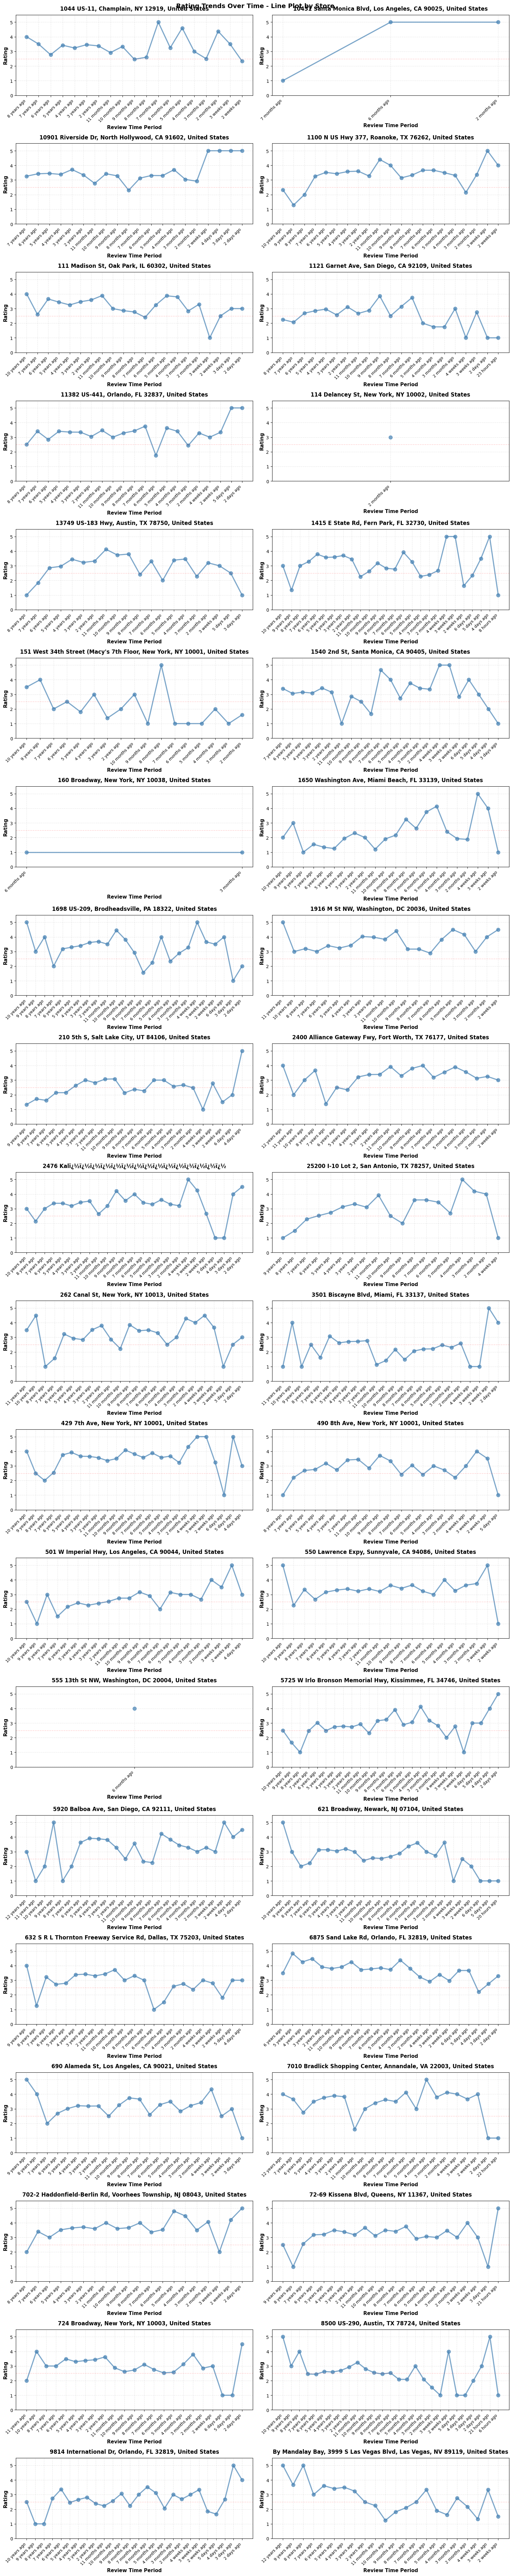

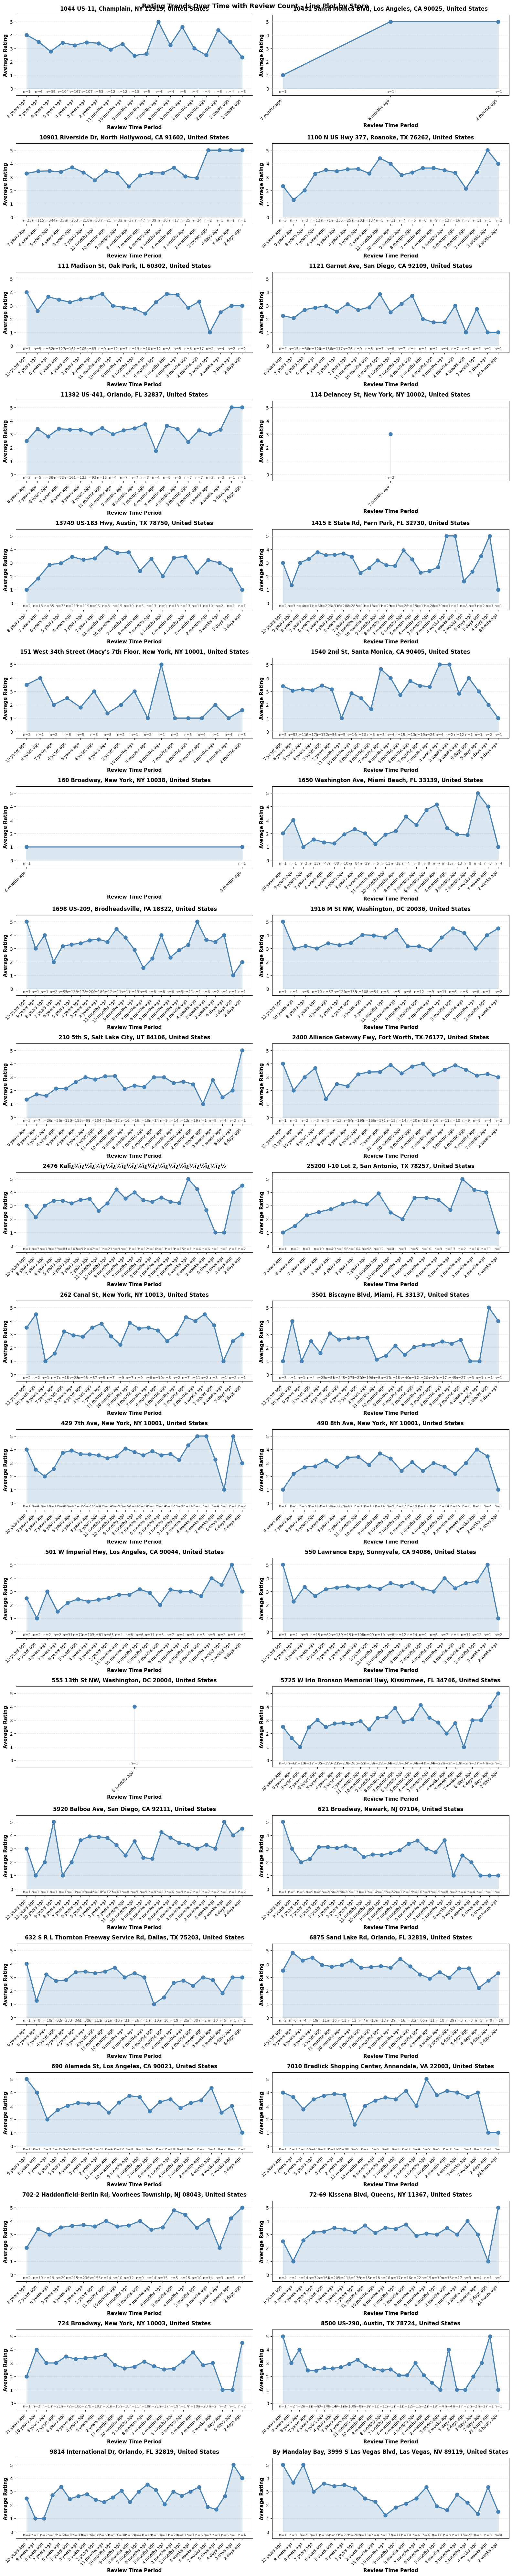

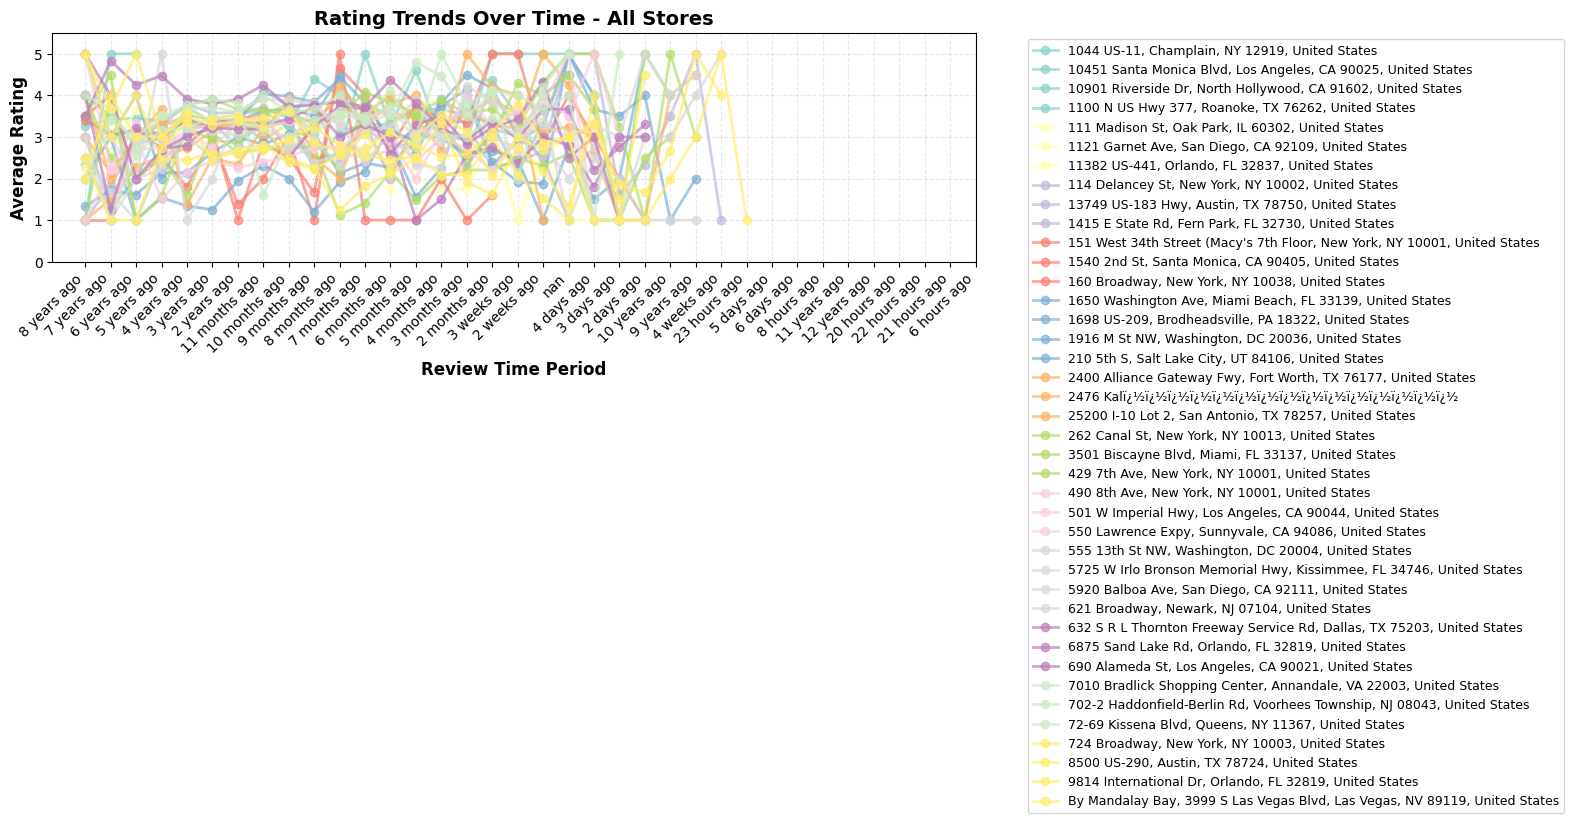

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import re
import numpy as np

# ============================================================================
# AUTO-SORT TIME PERIODS: 3,2,1 years → 12,11...1 months → weeks → days → hours
# ============================================================================

def get_time_sort_order(time_list):
    """
    Sort time periods: largest to smallest within each category
    Years (3,2,1) → Months (12,11...1) → Weeks → Days → Hours
    """

    def extract_number(time_str):
        match = re.match(r'(\d+)', time_str)
        return int(match.group(1)) if match else 0

    # Separate by type and sort DESCENDING (largest to smallest)
    years = sorted(
        [t for t in time_list if re.search(r'\d+\s*year', t.lower())],
        key=extract_number,
        reverse=True
    )

    months = sorted(
        [t for t in time_list if re.search(r'\d+\s*month', t.lower())],
        key=extract_number,
        reverse=True
    )

    weeks = sorted(
        [t for t in time_list if re.search(r'\d+\s*week', t.lower())],
        key=extract_number,
        reverse=True
    )

    days = sorted(
        [t for t in time_list if re.search(r'\d+\s*day', t.lower())],
        key=extract_number,
        reverse=True
    )

    hours = sorted(
        [t for t in time_list if re.search(r'\d+\s*hour', t.lower())],
        key=extract_number,
        reverse=True
    )

    return years + months + weeks + days + hours

time_order = get_time_sort_order(df['review_time'].unique().tolist())
print(f"Sorted time periods:\n{time_order}\n")

df_plot = df.copy()
df_plot['review_time'] = pd.Categorical(
    df_plot['review_time'],
    categories=time_order,
    ordered=True
)

df_plot = df_plot.sort_values(['store_address', 'review_time'])

# ============================================================================
# OPTION 1: LINE PLOT SUBPLOTS (One subplot per store)
# ============================================================================

stores = df_plot['store_address'].unique()
n_stores = len(stores)
n_cols = 2
n_rows = (n_stores + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for idx, store in enumerate(stores):
    ax = axes[idx]

    store_data = df_plot[df_plot['store_address'] == store]

    # Group by review_time and get mean rating (in case of duplicates)
    grouped = store_data.groupby('review_time', observed=True)['rating'].mean().reset_index()

    # Create x-axis numeric values for plotting
    x_vals = range(len(grouped))

    # Plot line
    ax.plot(x_vals, grouped['rating'],
            marker='o', linewidth=2.5, markersize=8,
            color='steelblue', alpha=0.7)

    # Styling
    ax.set_xticks(x_vals)
    ax.set_xticklabels(grouped['review_time'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Rating', fontsize=11, fontweight='bold')
    ax.set_xlabel('Review Time Period', fontsize=11, fontweight='bold')
    ax.set_title(f'{store}', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylim([0, 5.5])
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(y=2.5, color='red', linestyle='--', alpha=0.2, linewidth=1)  # Mid-line reference

# Hide unused subplots
for idx in range(len(stores), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Rating Trends Over Time - Line Plot by Store',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================================================
# OPTION 2: LINE PLOT WITH MULTIPLE STORES ON ONE AXES (FacetGrid style)
# ============================================================================

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, store in enumerate(stores):
    ax = axes[idx]

    store_data = df_plot[df_plot['store_address'] == store]
    grouped = store_data.groupby('review_time', observed=True)['rating'].agg(['mean', 'count']).reset_index()

    x_vals = range(len(grouped))

    # Plot with fill between for better visualization
    ax.fill_between(x_vals, grouped['mean'], alpha=0.2, color='steelblue')
    ax.plot(x_vals, grouped['mean'],
            marker='o', linewidth=2.5, markersize=8,
            color='steelblue', label='Average Rating')

    # Add count labels on points
    for x, count in zip(x_vals, grouped['count']):
        ax.text(x, -0.3, f'n={int(count)}', ha='center', fontsize=8, alpha=0.7)

    ax.set_xticks(x_vals)
    ax.set_xticklabels(grouped['review_time'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Average Rating', fontsize=11, fontweight='bold')
    ax.set_xlabel('Review Time Period', fontsize=11, fontweight='bold')
    ax.set_title(f'{store}', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylim([-0.5, 5.5])
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')

# Hide unused subplots
for idx in range(len(stores), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Rating Trends Over Time with Review Count - Line Plot by Store',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================================================
# OPTION 3: ALL STORES ON ONE PLOT (Different colors for each store)
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 6))

colors = plt.cm.Set3(np.linspace(0, 1, len(stores)))

for idx, store in enumerate(stores):
    store_data = df_plot[df_plot['store_address'] == store]
    grouped = store_data.groupby('review_time', observed=True)['rating'].mean().reset_index()

    x_vals = range(len(grouped))

    ax.plot(x_vals, grouped['rating'],
            marker='o', linewidth=2, markersize=6,
            label=store, color=colors[idx], alpha=0.7)

# Set x-axis labels (same for all stores)
all_time_periods = df_plot['review_time'].unique()
ax.set_xticks(range(len(all_time_periods)))
ax.set_xticklabels(all_time_periods, rotation=45, ha='right', fontsize=10)

ax.set_ylabel('Average Rating', fontsize=12, fontweight='bold')
ax.set_xlabel('Review Time Period', fontsize=12, fontweight='bold')
ax.set_title('Rating Trends Over Time - All Stores', fontsize=14, fontweight='bold')
ax.set_ylim([0, 5.5])
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# OPTION 4: SUMMARY TABLE OF DATA
# ============================================================================
"""
print("\n" + "="*100)
print("SUMMARY: Average Rating by Store and Time Period")
print("="*100)"""

summary = df_plot.groupby(['store_address', 'review_time'], observed=True).agg({
    'rating': ['mean', 'count', 'std']
}).round(2)

summary.columns = ['Avg Rating', 'Count', 'Std Dev']
#print(summary)

In [36]:
df_review

,review,rating
0,Why does it look like someone spit on my food?...,1
1,It'd McDonalds. It is what it is as far as the...,4
2,Made a mobile order got to the speaker and che...,1
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5
4,"I repeat my order 3 times in the drive thru, a...",1
...,...,...
33391,They treated me very badly.,1
33392,The service is very good,5
33393,To remove hunger is enough,4
33394,"It's good, but lately it has become very expen...",5


In [37]:
df

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
11906,11907,McDonald's,Fast food restaurant,"1044 US-11, Champlain, NY 12919, United States",44.981410,-73.459820,"1,306",10 months ago,I stop at this McDonald's like once a week or ...,3
11937,11938,McDonald's,Fast food restaurant,"1044 US-11, Champlain, NY 12919, United States",44.981410,-73.459820,"1,306",10 months ago,A complete joke I told them I wanted a medium ...,1
11960,11961,McDonald's,Fast food restaurant,"1044 US-11, Champlain, NY 12919, United States",44.981410,-73.459820,"1,306",10 months ago,McDonald's is not a place where I would normal...,3
11998,11999,McDonald's,Fast food restaurant,"1044 US-11, Champlain, NY 12919, United States",44.981410,-73.459820,"1,306",10 months ago,What staff they had were working hard but the ...,1
12008,12009,McDonald's,Fast food restaurant,"1044 US-11, Champlain, NY 12919, United States",44.981410,-73.459820,"1,306",10 months ago,Good service short waiting time friendly peopl...,5
...,...,...,...,...,...,...,...,...,...,...
22008,22009,McDonald's,Fast food restaurant,"By Mandalay Bay, 3999 S Las Vegas Blvd, Las Ve...",36.090244,-115.175822,"2,365",a year ago,normal mcdonald,4
22127,22128,McDonald's,Fast food restaurant,"By Mandalay Bay, 3999 S Las Vegas Blvd, Las Ve...",36.090244,-115.175822,"2,365",a year ago,"Cheap fast food in lkas vegas, it doesn't get ...",3
22129,22130,McDonald's,Fast food restaurant,"By Mandalay Bay, 3999 S Las Vegas Blvd, Las Ve...",36.090244,-115.175822,"2,365",a year ago,Today we had a very bad experience. We went on...,1
22133,22134,McDonald's,Fast food restaurant,"By Mandalay Bay, 3999 S Las Vegas Blvd, Las Ve...",36.090244,-115.175822,"2,365",a year ago,"Terrible attention, the employees ask them to ...",1


In [38]:
"""import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    data=df_grouped_count,
    x='review_time',
    y='count',
    hue='store_address'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()"""

"import matplotlib.pyplot as plt\nimport seaborn as sns\n\nplt.figure(figsize=(10,5))\nsns.barplot(\n    data=df_grouped_count,\n    x='review_time',\n    y='count',\n    hue='store_address'\n)\nplt.xticks(rotation=45)\nplt.tight_layout()\nplt.show()"

In [39]:
"""
df_sorted = df.sort_values(by='review_time')

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_sorted,
    x='review_time',
    y='count',
    hue='store_address',
    style='rating',
    markers=True,
    dashes=False
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()"""

"\ndf_sorted = df.sort_values(by='review_time')\n\n# Plot\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\nplt.figure(figsize=(10,5))\nsns.lineplot(\n    data=df_sorted,\n    x='review_time',\n    y='count',\n    hue='store_address',\n    style='rating',\n    markers=True,\n    dashes=False\n)\nplt.xticks(rotation=45)\nplt.tight_layout()\nplt.show()"

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

"""# Sample grouped data
df_grouped_count = pd.DataFrame({
    'store_address': ['Store A', 'Store A', 'Store B', 'Store B'],
    'rating': [5, 4, 5, 3],
    'review_time': ['3 months ago', '2 years ago', '1 month ago', '5 years ago'],
    'count': [10, 5, 8, 2]
})
plt.figure(figsize=(12,6))
sns.lineplot(
    data=grouped_count,
    x='review_time',
    y='count',
    hue='store_address',
    style='rating',
    markers=True,
    dashes=False
)

plt.title('Store Ratings Timeline')
plt.xlabel('Review Time')
plt.ylabel('Count of Ratings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()"""

"# Sample grouped data\ndf_grouped_count = pd.DataFrame({\n    'store_address': ['Store A', 'Store A', 'Store B', 'Store B'],\n    'rating': [5, 4, 5, 3],\n    'review_time': ['3 months ago', '2 years ago', '1 month ago', '5 years ago'],\n    'count': [10, 5, 8, 2]\n})\nplt.figure(figsize=(12,6))\nsns.lineplot(\n    data=grouped_count,\n    x='review_time',\n    y='count',\n    hue='store_address',\n    style='rating',\n    markers=True,\n    dashes=False\n)\n\nplt.title('Store Ratings Timeline')\nplt.xlabel('Review Time')\nplt.ylabel('Count of Ratings')\nplt.xticks(rotation=45)\nplt.tight_layout()\nplt.show()"

In [41]:
"""
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import re

# Sample data (replace with your actual dataframe)
#sample_data = pivot_table
#df = pd.DataFrame(sample_data)
# review_time
#df_pivot = pivot_table
df_pivot = df.copy()

def parse_relative_time(time_str):
    #Convert relative time strings to actual dates
    today = datetime.now()
    time_str = time_str.lower().strip()

    # Extract number and unit using regex
    match = re.search(r'(\d+)\s*(day|week|month|year)', time_str)
    if not match:
        return today  # fallback for unparseable strings

    number = int(match.group(1))
    unit = match.group(2)

    if 'day' in unit:
        return today - timedelta(days=number)
    elif 'week' in unit:
        return today - timedelta(weeks=number)
    elif 'month' in unit:
        return today - timedelta(days=number * 30)  # approximate
    elif 'year' in unit:
        return today - timedelta(days=number * 365)  # approximate

    return today

# Convert review_time to actual dates
df_pivot['review_date'] = df_pivot['review_time'].apply(parse_relative_time)
df_pivot['review_date'] = pd.to_datetime(df_pivot['review_date'])

print("Data after parsing review times:")
print(df_pivot[['review_time', 'review_date', 'rating']])
print("\n" + "="*50 + "\n")

# Group by review_date and rating, then count occurrences
grouped = df_pivot.groupby(['review_date', 'rating']).size().reset_index(name='count')
print("Grouped data:")
print(grouped)
print("\n" + "="*50 + "\n")

# Method 1: Line plot showing count of reviews over time for each rating
plt.figure(figsize=(12, 8))

# Plot separate lines for each rating
for rating in sorted(df_pivot['rating'].unique()):
    rating_data = grouped[grouped['rating'] == rating]
    plt.plot(rating_data['review_date'], rating_data['count'],
             marker='o', label=f'Rating {rating}', linewidth=2, markersize=6)

plt.title('Review Count Over Time by Rating', fontsize=16, fontweight='bold')
plt.xlabel('Review Date', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Date range: {df_pivot['review_date'].min().strftime('%Y-%m-%d')} to {df_pivot['review_date'].max().strftime('%Y-%m-%d')}")
print(f"Total reviews: {len(df_pivot)}")
print(f"Average rating: {df_pivot['rating'].mean():.2f}")
print(f"Rating distribution:")
print(df_pivot['rating'].value_counts().sort_index())"""

'\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport numpy as np\nfrom datetime import datetime, timedelta\nimport re\n\n# Sample data (replace with your actual dataframe)\n#sample_data = pivot_table\n#df = pd.DataFrame(sample_data)\n# review_time\n#df_pivot = pivot_table\ndf_pivot = df.copy()\n\ndef parse_relative_time(time_str):\n    #Convert relative time strings to actual dates\n    today = datetime.now()\n    time_str = time_str.lower().strip()\n\n    # Extract number and unit using regex\n    match = re.search(r\'(\\d+)\\s*(day|week|month|year)\', time_str)\n    if not match:\n        return today  # fallback for unparseable strings\n\n    number = int(match.group(1))\n    unit = match.group(2)\n\n    if \'day\' in unit:\n        return today - timedelta(days=number)\n    elif \'week\' in unit:\n        return today - timedelta(weeks=number)\n    elif \'month\' in unit:\n        return today - timedelta(days=number * 30)  # approximate\n    elif \'year\' in unit:\n    

In [42]:
"""
#groupby review_time , rating
df['review_time_edit'] = pd.to_datetime(df['review_time'], format='%M %Y', errors='coerce')
# or if abbreviated month: format='%b %Y'
# Optional: Group by month instead of exact timestamp
df['review_month_edit'] = df['review_time_edit'].dt.to_period('M').astype(str)

# Count number of reviews per month per rating
grouped = df.groupby(['review_month_edit', 'rating']).size().reset_index(name='count')

pivot_df = grouped.pivot(index='review_month_edit', columns='rating', values='count').fillna(0)"""

"\n#groupby review_time , rating\ndf['review_time_edit'] = pd.to_datetime(df['review_time'], format='%M %Y', errors='coerce')\n# or if abbreviated month: format='%b %Y'\n# Optional: Group by month instead of exact timestamp\ndf['review_month_edit'] = df['review_time_edit'].dt.to_period('M').astype(str)\n\n# Count number of reviews per month per rating\ngrouped = df.groupby(['review_month_edit', 'rating']).size().reset_index(name='count')\n\npivot_df = grouped.pivot(index='review_month_edit', columns='rating', values='count').fillna(0)"

In [43]:
"""import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for rating in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[rating], marker='o', label=f'Rating {rating}')

plt.title('Review Count per Rating Over Time (Line Plot)')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Rating')
plt.tight_layout()
plt.show()"""

"import matplotlib.pyplot as plt\n\nplt.figure(figsize=(14, 7))\n\nfor rating in pivot_df.columns:\n    plt.plot(pivot_df.index, pivot_df[rating], marker='o', label=f'Rating {rating}')\n\nplt.title('Review Count per Rating Over Time (Line Plot)')\nplt.xlabel('Month')\nplt.ylabel('Number of Reviews')\nplt.xticks(rotation=45)\nplt.legend(title='Rating')\nplt.tight_layout()\nplt.show()"

In [44]:
df_review

,review,rating
0,Why does it look like someone spit on my food?...,1
1,It'd McDonalds. It is what it is as far as the...,4
2,Made a mobile order got to the speaker and che...,1
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5
4,"I repeat my order 3 times in the drive thru, a...",1
...,...,...
33391,They treated me very badly.,1
33392,The service is very good,5
33393,To remove hunger is enough,4
33394,"It's good, but lately it has become very expen...",5


In [45]:
"""
df['review_time'] = pd.to_datetime(df['review_time'], errors='coerce')  # auto-detect format
df['month_year'] = df['review_time'].dt.strftime('%b-%Y')  # e.g., "Aug-2023"
grouped = df.groupby(['month_year', 'rating']).size().reset_index(name='count')
pivot_df = grouped.pivot(index='month_year', columns='rating', values='count').fillna(0)

# Sort by actual date, not string
pivot_df.index = pd.to_datetime(pivot_df.index, format='%b-%Y')  # or '%Y-%m'
pivot_df = pivot_df.sort_index()"""

'\ndf[\'review_time\'] = pd.to_datetime(df[\'review_time\'], errors=\'coerce\')  # auto-detect format\ndf[\'month_year\'] = df[\'review_time\'].dt.strftime(\'%b-%Y\')  # e.g., "Aug-2023"\ngrouped = df.groupby([\'month_year\', \'rating\']).size().reset_index(name=\'count\')\npivot_df = grouped.pivot(index=\'month_year\', columns=\'rating\', values=\'count\').fillna(0)\n\n# Sort by actual date, not string\npivot_df.index = pd.to_datetime(pivot_df.index, format=\'%b-%Y\')  # or \'%Y-%m\'\npivot_df = pivot_df.sort_index()'

In [46]:
"""
#pivot_df.index = pd.to_datetime(pivot_df.index)  # For sorting if needed
pivot_df = pivot_df.sort_index()  # Sort by time

pivot_df.plot(kind='bar', figsize=(16, 8), width=0.8)

plt.title('Review Count per Rating Over Time (Bar Plot)')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Rating')
plt.tight_layout()
plt.show()"""

"\n#pivot_df.index = pd.to_datetime(pivot_df.index)  # For sorting if needed\npivot_df = pivot_df.sort_index()  # Sort by time\n\npivot_df.plot(kind='bar', figsize=(16, 8), width=0.8)\n\nplt.title('Review Count per Rating Over Time (Bar Plot)')\nplt.xlabel('Month')\nplt.ylabel('Number of Reviews')\nplt.xticks(rotation=45)\nplt.legend(title='Rating')\nplt.tight_layout()\nplt.show()"

In [47]:
"""
# df = df.sort_values('review_time')

df = df.sort_values(
    by='review_time',
    key=lambda x: x.str.extract('(\d+)').astype(int)[0]
)

df['review_time'] = df['review_time'].astype(str)

df = df.sort_values(
    by='review_time',
    key=lambda x: x.str.extract('(\d+)')[0].astype(int)
)

grouped = df.groupby(['review_time', 'rating']).size().reset_index(name='count')

pivot_df = grouped.pivot(
    index='review_time',
    columns='rating',
    values='count'
).fillna(0)

pivot_df.plot(kind='bar', figsize=(16,8))

plt.title('Review Count per Rating')
plt.xlabel('Review Time')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Rating')
plt.tight_layout()
plt.show()"""

"\n# df = df.sort_values('review_time')\n\ndf = df.sort_values(\n    by='review_time',\n    key=lambda x: x.str.extract('(\\d+)').astype(int)[0]\n)\n\ndf['review_time'] = df['review_time'].astype(str)\n\ndf = df.sort_values(\n    by='review_time',\n    key=lambda x: x.str.extract('(\\d+)')[0].astype(int)\n)\n\ngrouped = df.groupby(['review_time', 'rating']).size().reset_index(name='count')\n\npivot_df = grouped.pivot(\n    index='review_time',\n    columns='rating',\n    values='count'\n).fillna(0)\n\npivot_df.plot(kind='bar', figsize=(16,8))\n\nplt.title('Review Count per Rating')\nplt.xlabel('Review Time')\nplt.ylabel('Number of Reviews')\nplt.xticks(rotation=45)\nplt.legend(title='Rating')\nplt.tight_layout()\nplt.show()"

In [48]:
"""import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for rating in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[rating], marker='o', label=f'Rating {rating}')

# Format x-axis to show Month-Year
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b-%Y'))

plt.title('Review Count per Rating Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Rating')
plt.tight_layout()
plt.show()"""

"import matplotlib.pyplot as plt\n\nplt.figure(figsize=(14, 7))\n\nfor rating in pivot_df.columns:\n    plt.plot(pivot_df.index, pivot_df[rating], marker='o', label=f'Rating {rating}')\n\n# Format x-axis to show Month-Year\nplt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b-%Y'))\n\nplt.title('Review Count per Rating Over Time')\nplt.xlabel('Month-Year')\nplt.ylabel('Number of Reviews')\nplt.xticks(rotation=45)\nplt.legend(title='Rating')\nplt.tight_layout()\nplt.show()"

In [49]:
#df_review = df[['review','rating']].copy()
df_review

,review,rating
0,Why does it look like someone spit on my food?...,1
1,It'd McDonalds. It is what it is as far as the...,4
2,Made a mobile order got to the speaker and che...,1
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5
4,"I repeat my order 3 times in the drive thru, a...",1
...,...,...
33391,They treated me very badly.,1
33392,The service is very good,5
33393,To remove hunger is enough,4
33394,"It's good, but lately it has become very expen...",5


In [50]:
pip install contractions

Note: you may need to restart the kernel to use updated packages.


In [51]:
import contractions

def safe_fix(text):
    try:
        return contractions.fix(text)
    except Exception:
        return text

df_review['expanded_review'] = df_review['review'].apply(lambda x: safe_fix(x) if isinstance(x, str) else x)

In [52]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to C:\Users\Enter
[nltk_data]     Store\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Enter
[nltk_data]     Store\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [53]:
import re
import string
import pandas as pd
from tqdm import tqdm
from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, LancasterStemmer, SnowballStemmer, WordNetLemmatizer

tqdm.pandas()

def clean_text(text, spell_correct=False, remove_stopwords=True):
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+|https\S+', '', text)

    # 3. Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # 3. REMOVE datetime FIRST ✅
    text = re.sub(
        r'on\s+\w+,\s+\d{4}-\d{2}-\d{2}\s+at\s+\d{1,2}:\d{2}',
        '',
        text,
        flags=re.IGNORECASE
    )

    # 4. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 5. Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # 6. Remove hashtags (#hashtag)
    text = re.sub(r'#\w+', '', text)

    # 7. Remove repeated characters (heeeello -> helo)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # 8. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 9. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 10. Remove extra whitespace
    text = ' '.join(text.split())

    # 11. Tokenize
    tokens = text.split()

    # 12. Remove stopwords (optional)
    if remove_stopwords:
        stop_words = set(stopwords.words("english"))
        tokens = [w for w in tokens if w not in stop_words and len(w) >= 2]
    else:
        # Just filter short words
        tokens = [w for w in tokens if len(w) >= 2]
    """
    # 13. Spell correction (optional and SLOW)
    if spell_correct:
        tokens = [str(TextBlob(w).correct()) for w in tokens]
    """
    # Return cleaned tokens as string
    return ' '.join(tokens)


# Step 1: Clean the text
df_review['cleaned_review'] = df_review['expanded_review'].progress_apply(
    lambda x: clean_text(x, spell_correct=False, remove_stopwords=True)
)

print(f"Cleaning completed. Sample:\n{df_review['cleaned_review'].head(3)}")

100%|██████████████████████████████████████████████████████████████████████████| 33396/33396 [00:08<00:00, 3828.68it/s]

Cleaning completed. Sample:
0    look like someone spit food normal transaction...
1    would mcdonalds far food atmosphere go staff m...
2    made mobile order got speaker checked line mov...
Name: cleaned_review, dtype: object


In [54]:
import nltk
def tokenize_sentence(text):
  word_token = nltk.word_tokenize(text)
  sentance_token = nltk.sent_tokenize(text)

  return word_token

df_review['token_review']= df_review['cleaned_review'].progress_apply(tokenize_sentence)

100%|█████████████████████████████████████████████████████████████████████████| 33396/33396 [00:02<00:00, 14288.68it/s]


In [55]:
df_review

,review,rating,expanded_review,cleaned_review,token_review
0,Why does it look like someone spit on my food?...,1,Why does it look like someone spit on my food?...,look like someone spit food normal transaction...,"[look, like, someone, spit, food, normal, tran..."
1,It'd McDonalds. It is what it is as far as the...,4,It would McDonalds. It is what it is as far as...,would mcdonalds far food atmosphere go staff m...,"[would, mcdonalds, far, food, atmosphere, go, ..."
2,Made a mobile order got to the speaker and che...,1,Made a mobile order got to the speaker and che...,made mobile order got speaker checked line mov...,"[made, mobile, order, got, speaker, checked, l..."
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,mc crispy chicken sandwich ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï...,"[mc, crispy, chicken, sandwich, ï¿½ï¿½ï¿½ï¿½ï¿..."
4,"I repeat my order 3 times in the drive thru, a...",1,"I repeat my order 3 times in the drive thru, a...",repeat order times drive thru still manage mes...,"[repeat, order, times, drive, thru, still, man..."
...,...,...,...,...,...
33391,They treated me very badly.,1,They treated me very badly.,treated badly,"[treated, badly]"
33392,The service is very good,5,The service is very good,service good,"[service, good]"
33393,To remove hunger is enough,4,To remove hunger is enough,remove hunger enough,"[remove, hunger, enough]"
33394,"It's good, but lately it has become very expen...",5,"It is good, but lately it has become very expe...",good lately become expensive,"[good, lately, become, expensive]"


In [56]:
!pip install pyspellchecker

In [57]:
"""import os
import pickle
from tqdm.notebook import tqdm
from spellchecker import SpellChecker

def correct_spelling_with_checkpoints(
    df_review,
    input_col,
    output_col,
    checkpoint_dir='my_checkpoints',
    save_every=100
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_file = os.path.join(checkpoint_dir, 'spelling.pkl')

    results = {}
    start_idx = 0

    if os.path.exists(checkpoint_file):
        try:
            with open(checkpoint_file, 'rb') as f:
                checkpoint = pickle.load(f)
            results = checkpoint['results']
            start_idx = checkpoint['last_index'] + 1
            print(f"📂 Resuming from row {start_idx}")
        except:
    print("⚠️ Checkpoint corrupted, restarting")
    else:
        print("🆕 Starting spelling correction")

    spell = SpellChecker()

    for idx in tqdm(range(start_idx, len(df_review)), desc="Spell check"):
        tokens = df_review.iloc[idx][input_col]

        if isinstance(tokens, list):
            corrected = [spell.correction(t) if t else t for t in tokens]
        else:
            corrected = tokens

        results[idx] = corrected

        if (idx + 1) % save_every == 0:
            with open(checkpoint_file, 'wb') as f:
                pickle.dump({'results': results, 'last_index': idx}, f)

    with open(checkpoint_file, 'wb') as f:
        pickle.dump({'results': results, 'last_index': len(df_review) - 1}, f)

    df_review[output_col] = [results.get(i) for i in range(len(df_review))]
    print("✅ Complete!")

    return df_review

# Run it
df_review = correct_spelling_with_checkpoints(
    df_review,
    input_col='token_review',
    output_col='tokens_correctspelling',
    checkpoint_dir='my_checkpoints',
    save_every=100
)"""

'import os\nimport pickle\nfrom tqdm.notebook import tqdm\nfrom spellchecker import SpellChecker\n\ndef correct_spelling_with_checkpoints(\n    df_review,\n    input_col,\n    output_col,\n    checkpoint_dir=\'my_checkpoints\',\n    save_every=100\n):\n    os.makedirs(checkpoint_dir, exist_ok=True)\n    checkpoint_file = os.path.join(checkpoint_dir, \'spelling.pkl\')\n\n    results = {}\n    start_idx = 0\n\n    if os.path.exists(checkpoint_file):\n        try:\n            with open(checkpoint_file, \'rb\') as f:\n                checkpoint = pickle.load(f)\n            results = checkpoint[\'results\']\n            start_idx = checkpoint[\'last_index\'] + 1\n            print(f"📂 Resuming from row {start_idx}")\n        except:\n    print("⚠️ Checkpoint corrupted, restarting")\n    else:\n        print("🆕 Starting spelling correction")\n\n    spell = SpellChecker()\n\n    for idx in tqdm(range(start_idx, len(df_review)), desc="Spell check"):\n        tokens = df_review.iloc[idx][inpu

In [58]:
"""def correct_spelling_with_checkpoints(
    df_review, input_col, output_col,
    checkpoint_dir='my_checkpoints', save_every=100):

    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_file = os.path.join(checkpoint_dir, 'spelling.pkl')
    csv_checkpoint = os.path.join(checkpoint_dir, 'spelling_checkpoint.csv')

    results = {}
    start_idx = 0

    # ✅ Reset index to guarantee 0,1,2,3... alignment
    df_review = df_review.reset_index(drop=True)

    if os.path.exists(checkpoint_file):
        try:
            with open(checkpoint_file, 'rb') as f:
                checkpoint = pickle.load(f)
            results = checkpoint['results']
            start_idx = checkpoint['last_index'] + 1
            print(f"📂 Resuming from row {start_idx} / {len(df_review)}")
        except Exception as e:
            print(f"⚠️ Checkpoint corrupted ({e}), restarting")
    else:
        print("🆕 Starting spelling correction")

    spell = SpellChecker()

    for idx in tqdm(range(start_idx, len(df_review)), desc="Spell check"):
        tokens = df_review.iloc[idx][input_col]

        if isinstance(tokens, list):
            corrected = [
                # ✅ Guard against None returned by spell.correction()
                (spell.correction(t) or t) if t else t
                for t in tokens
            ]
        else:
            corrected = tokens

        results[idx] = corrected

        # ✅ Save every N rows
        if (idx + 1) % save_every == 0:
            with open(checkpoint_file, 'wb') as f:
                pickle.dump({'results': results, 'last_index': idx}, f)
            df_review[output_col] = [results.get(i) for i in range(len(df_review))]
            df_review.to_csv(csv_checkpoint, index=False)
            print(f"💾 Checkpoint saved at row {idx + 1}")

    # ✅ Final save
    with open(checkpoint_file, 'wb') as f:
        pickle.dump({'results': results, 'last_index': len(df_review) - 1}, f)

    df_review[output_col] = [results.get(i) for i in range(len(df_review))]
    df_review.to_csv(csv_checkpoint, index=False)
    print("✅ Complete!")

    return df_review

# Run it
df_review = correct_spelling_with_checkpoints(
    df_review,
    input_col='token_review',
    output_col='tokens_correctspelling',
    checkpoint_dir='my_checkpoints',
    save_every=100
)"""

'def correct_spelling_with_checkpoints(\n    df_review, input_col, output_col,\n    checkpoint_dir=\'my_checkpoints\', save_every=100):\n\n    os.makedirs(checkpoint_dir, exist_ok=True)\n    checkpoint_file = os.path.join(checkpoint_dir, \'spelling.pkl\')\n    csv_checkpoint = os.path.join(checkpoint_dir, \'spelling_checkpoint.csv\')\n\n    results = {}\n    start_idx = 0\n\n    # ✅ Reset index to guarantee 0,1,2,3... alignment\n    df_review = df_review.reset_index(drop=True)\n\n    if os.path.exists(checkpoint_file):\n        try:\n            with open(checkpoint_file, \'rb\') as f:\n                checkpoint = pickle.load(f)\n            results = checkpoint[\'results\']\n            start_idx = checkpoint[\'last_index\'] + 1\n            print(f"📂 Resuming from row {start_idx} / {len(df_review)}")\n        except Exception as e:\n            print(f"⚠️ Checkpoint corrupted ({e}), restarting")\n    else:\n        print("🆕 Starting spelling correction")\n\n    spell = SpellChecker(

In [59]:
import os
import pickle
from tqdm.notebook import tqdm
from spellchecker import SpellChecker

def correct_spelling_with_checkpoints(
    df_review, input_col, output_col,
    checkpoint_dir='my_checkpoints', save_every=100
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_file = os.path.join(checkpoint_dir, 'spelling.pkl')
    csv_checkpoint = os.path.join(checkpoint_dir, 'spelling_checkpoint.csv')

    df_review = df_review.reset_index(drop=True)

    # ✅ If already fully completed — just load and return
    if os.path.exists(csv_checkpoint):
        saved_df = pd.read_csv(csv_checkpoint)
        if output_col in saved_df.columns and saved_df[output_col].notna().all():
            print(f"✅ Already completed! Loading saved data from '{csv_checkpoint}'")
            print(f"📊 Shape: {saved_df.shape}")
            return saved_df

    results = {}
    start_idx = 0

    if os.path.exists(checkpoint_file):
        try:
            with open(checkpoint_file, 'rb') as f:
                checkpoint = pickle.load(f)
            results = checkpoint['results']
            start_idx = checkpoint['last_index'] + 1
            print(f"📂 Resuming from row {start_idx} / {len(df_review)}")
        except Exception as e:
            print(f"⚠️ Checkpoint corrupted ({e}), restarting")
    else:
        print("🆕 Starting spelling correction")

    spell = SpellChecker()

    for idx in tqdm(range(start_idx, len(df_review)), desc="Spell check"):
        tokens = df_review.iloc[idx][input_col]

        if isinstance(tokens, list):
            corrected = [
                (spell.correction(t) or t) if t else t
                for t in tokens
            ]
        else:
            corrected = tokens

        results[idx] = corrected

        if (idx + 1) % save_every == 0:
            with open(checkpoint_file, 'wb') as f:
                pickle.dump({'results': results, 'last_index': idx}, f)
            df_review[output_col] = [results.get(i) for i in range(len(df_review))]
            df_review.to_csv(csv_checkpoint, index=False)
            print(f"💾 Checkpoint saved at row {idx + 1}")

    # Final save
    with open(checkpoint_file, 'wb') as f:
        pickle.dump({'results': results, 'last_index': len(df_review) - 1}, f)

    df_review[output_col] = [results.get(i) for i in range(len(df_review))]
    df_review.to_csv(csv_checkpoint, index=False)
    print("✅ Complete! Data saved.")

    return df_review


# ▶️ Run it
df_review = correct_spelling_with_checkpoints(
    df_review,
    input_col='token_review',
    output_col='tokens_correctspelling',
    checkpoint_dir='my_checkpoints',
    save_every=100
)

✅ Already completed! Loading saved data from 'my_checkpoints\spelling_checkpoint.csv'
📊 Shape: (33396, 6)


In [60]:
df_review

,review,rating,expanded_review,cleaned_review,token_review,tokens_correctspelling
0,Why does it look like someone spit on my food?...,1,Why does it look like someone spit on my food?...,look like someone spit food normal transaction...,"['look', 'like', 'someone', 'spit', 'food', 'n...",['good']
1,It'd McDonalds. It is what it is as far as the...,4,It would McDonalds. It is what it is as far as...,would mcdonalds far food atmosphere go staff m...,"['would', 'mcdonalds', 'far', 'food', 'atmosph...","['love', 'ape', 'much', 'using', 'notify', 'ye..."
2,Made a mobile order got to the speaker and che...,1,Made a mobile order got to the speaker and che...,made mobile order got speaker checked line mov...,"['made', 'mobile', 'order', 'got', 'speaker', ...",['perfect']
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,mc crispy chicken sandwich ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï...,"['mc', 'crispy', 'chicken', 'sandwich', 'ï¿½ï¿...","['best', 'around', 'music', 'streaming', 'ape'..."
4,"I repeat my order 3 times in the drive thru, a...",1,"I repeat my order 3 times in the drive thru, a...",repeat order times drive thru still manage mes...,"['repeat', 'order', 'times', 'drive', 'thru', ...","['fr', 'safekeeping', 'play', 'button', 'songs']"
...,...,...,...,...,...,...
33391,They treated me very badly.,1,They treated me very badly.,treated badly,"['treated', 'badly']","['pay', 'premium', 'thing', 'bugs', 'every', '..."
33392,The service is very good,5,The service is very good,service good,"['service', 'good']","['fairly', 'okay', 'major', 'downsides', 'butt..."
33393,To remove hunger is enough,4,To remove hunger is enough,remove hunger enough,"['remove', 'hunger', 'enough']","['notify', 'easy', 'use', 'sound', 'quality', ..."
33394,"It's good, but lately it has become very expen...",5,"It is good, but lately it has become very expe...",good lately become expensive,"['good', 'lately', 'become', 'expensive']","['notify', 'great', 'music', 'ape', 'make', 'p..."


In [61]:
"""
import os
import pickle
import pandas as pd
from tqdm.notebook import tqdm
from spellchecker import SpellChecker

def correct_spelling_with_checkpoints(
    df_review,
    input_col,
    output_col,
    checkpoint_dir='my_checkpoints',
    save_every=100
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_file = os.path.join(checkpoint_dir, 'spelling.pkl')
    csv_checkpoint = os.path.join(checkpoint_dir, 'spelling_checkpoint.csv')

    results = {}
    start_idx = 0

    if os.path.exists(checkpoint_file):
        try:
            with open(checkpoint_file, 'rb') as f:
                checkpoint = pickle.load(f)
            results = checkpoint['results']
            start_idx = checkpoint['last_index'] + 1
            print(f"📂 Resuming from row {start_idx}")
        except:
            print("⚠️ Checkpoint corrupted, restarting")
    else:
        print("🆕 Starting spelling correction")

    spell = SpellChecker()

    for idx in tqdm(range(start_idx, len(df_review)), desc="Spell check"):
        tokens = df_review.iloc[idx][input_col]

        if isinstance(tokens, list):
            corrected = [spell.correction(t) if t else t for t in tokens]
        else:
            corrected = tokens

        results[idx] = corrected

        if (idx + 1) % save_every == 0:
            with open(checkpoint_file, 'wb') as f:
                pickle.dump({'results': results, 'last_index': idx}, f)

            df_review[output_col] = [results.get(i) for i in range(len(df_review))]
            df_review.to_csv(csv_checkpoint, index=False)

            print(f"💾 Saved checkpoint at row {idx + 1}")

    with open(checkpoint_file, 'wb') as f:
        pickle.dump({'results': results, 'last_index': len(df_review) - 1}, f)

    df_review[output_col] = [results.get(i) for i in range(len(df_review))]
    df_review.to_csv(csv_checkpoint, index=False)

    print(f"✅ Complete!")

    return df_review

# Run it
df_review = correct_spelling_with_checkpoints(
    df_review,
    input_col='token_review',
    output_col='tokens_correctspelling',
    checkpoint_dir='my_checkpoints',
    save_every=100
)"""

'\nimport os\nimport pickle\nimport pandas as pd\nfrom tqdm.notebook import tqdm\nfrom spellchecker import SpellChecker\n\ndef correct_spelling_with_checkpoints(\n    df_review,\n    input_col,\n    output_col,\n    checkpoint_dir=\'my_checkpoints\',\n    save_every=100\n):\n    os.makedirs(checkpoint_dir, exist_ok=True)\n    checkpoint_file = os.path.join(checkpoint_dir, \'spelling.pkl\')\n    csv_checkpoint = os.path.join(checkpoint_dir, \'spelling_checkpoint.csv\')\n\n    results = {}\n    start_idx = 0\n\n    if os.path.exists(checkpoint_file):\n        try:\n            with open(checkpoint_file, \'rb\') as f:\n                checkpoint = pickle.load(f)\n            results = checkpoint[\'results\']\n            start_idx = checkpoint[\'last_index\'] + 1\n            print(f"📂 Resuming from row {start_idx}")\n        except:\n            print("⚠️ Checkpoint corrupted, restarting")\n    else:\n        print("🆕 Starting spelling correction")\n\n    spell = SpellChecker()\n\n    fo

In [62]:
df_review

,review,rating,expanded_review,cleaned_review,token_review,tokens_correctspelling
0,Why does it look like someone spit on my food?...,1,Why does it look like someone spit on my food?...,look like someone spit food normal transaction...,"['look', 'like', 'someone', 'spit', 'food', 'n...",['good']
1,It'd McDonalds. It is what it is as far as the...,4,It would McDonalds. It is what it is as far as...,would mcdonalds far food atmosphere go staff m...,"['would', 'mcdonalds', 'far', 'food', 'atmosph...","['love', 'ape', 'much', 'using', 'notify', 'ye..."
2,Made a mobile order got to the speaker and che...,1,Made a mobile order got to the speaker and che...,made mobile order got speaker checked line mov...,"['made', 'mobile', 'order', 'got', 'speaker', ...",['perfect']
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,mc crispy chicken sandwich ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï...,"['mc', 'crispy', 'chicken', 'sandwich', 'ï¿½ï¿...","['best', 'around', 'music', 'streaming', 'ape'..."
4,"I repeat my order 3 times in the drive thru, a...",1,"I repeat my order 3 times in the drive thru, a...",repeat order times drive thru still manage mes...,"['repeat', 'order', 'times', 'drive', 'thru', ...","['fr', 'safekeeping', 'play', 'button', 'songs']"
...,...,...,...,...,...,...
33391,They treated me very badly.,1,They treated me very badly.,treated badly,"['treated', 'badly']","['pay', 'premium', 'thing', 'bugs', 'every', '..."
33392,The service is very good,5,The service is very good,service good,"['service', 'good']","['fairly', 'okay', 'major', 'downsides', 'butt..."
33393,To remove hunger is enough,4,To remove hunger is enough,remove hunger enough,"['remove', 'hunger', 'enough']","['notify', 'easy', 'use', 'sound', 'quality', ..."
33394,"It's good, but lately it has become very expen...",5,"It is good, but lately it has become very expe...",good lately become expensive,"['good', 'lately', 'become', 'expensive']","['notify', 'great', 'music', 'ape', 'make', 'p..."


In [63]:
#df_review['review_time'].head()
df['review_time'].head()

11906    10 months ago
11937    10 months ago
11960    10 months ago
11998    10 months ago
12008    10 months ago
Name: review_time, dtype: object

In [64]:
df_grouped = df_review.merge(
    df,
    on='review',
    how='left'
)

df_grouped.head()

,review,rating_x,expanded_review,cleaned_review,token_review,tokens_correctspelling,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,rating_y
0,Why does it look like someone spit on my food?...,1,Why does it look like someone spit on my food?...,look like someone spit food normal transaction...,"['look', 'like', 'someone', 'spit', 'food', 'n...",['good'],1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,1
1,It'd McDonalds. It is what it is as far as the...,4,It would McDonalds. It is what it is as far as...,would mcdonalds far food atmosphere go staff m...,"['would', 'mcdonalds', 'far', 'food', 'atmosph...","['love', 'ape', 'much', 'using', 'notify', 'ye...",2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,4
2,Made a mobile order got to the speaker and che...,1,Made a mobile order got to the speaker and che...,made mobile order got speaker checked line mov...,"['made', 'mobile', 'order', 'got', 'speaker', ...",['perfect'],3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,1
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,mc crispy chicken sandwich ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï...,"['mc', 'crispy', 'chicken', 'sandwich', 'ï¿½ï¿...","['best', 'around', 'music', 'streaming', 'ape'...",4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,5
4,"I repeat my order 3 times in the drive thru, a...",1,"I repeat my order 3 times in the drive thru, a...",repeat order times drive thru still manage mes...,"['repeat', 'order', 'times', 'drive', 'thru', ...","['fr', 'safekeeping', 'play', 'button', 'songs']",5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,1


In [65]:
import os

# Path to save
save_path = r"D:\Macreview"  # change this to your desired folder

# Create folder if it doesn't exist
os.makedirs(save_path, exist_ok=True)

# Save CSV
df_grouped.to_csv(os.path.join(save_path, "mcdonalds-store-reviews_cleaned.csv"), index=False)

print("✅ File saved on D: drive")

✅ File saved on D: drive


In [70]:
df_final = pd.read_csv(
    r'D:\Macreview\mcdonalds-store-reviews_cleaned.csv',
    encoding='latin-1'
)

print(df_final.head())

                                              review  rating_x  \
0  Why does it look like someone spit on my food?...         1   
1  It'd McDonalds. It is what it is as far as the...         4   
2  Made a mobile order got to the speaker and che...         1   
3  My mc. Crispy chicken sandwich was Ã¯Â¿Â½Ã¯Â¿Â...         5   
4  I repeat my order 3 times in the drive thru, a...         1   

                                     expanded_review  \
0  Why does it look like someone spit on my food?...   
1  It would McDonalds. It is what it is as far as...   
2  Made a mobile order got to the speaker and che...   
3  My mc. Crispy chicken sandwich was Ã¯Â¿Â½Ã¯Â¿Â...   
4  I repeat my order 3 times in the drive thru, a...   

                                      cleaned_review  \
0  look like someone spit food normal transaction...   
1  would mcdonalds far food atmosphere go staff m...   
2  made mobile order got speaker checked line mov...   
3  mc crispy chicken sandwich Ã¯Â¿Â½Ã¯Â¿Â½

In [71]:
df_final.head()

,review,rating_x,expanded_review,cleaned_review,token_review,tokens_correctspelling,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,rating_y
0,Why does it look like someone spit on my food?...,1,Why does it look like someone spit on my food?...,look like someone spit food normal transaction...,"['look', 'like', 'someone', 'spit', 'food', 'n...",['good'],1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,1
1,It'd McDonalds. It is what it is as far as the...,4,It would McDonalds. It is what it is as far as...,would mcdonalds far food atmosphere go staff m...,"['would', 'mcdonalds', 'far', 'food', 'atmosph...","['love', 'ape', 'much', 'using', 'notify', 'ye...",2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,4
2,Made a mobile order got to the speaker and che...,1,Made a mobile order got to the speaker and che...,made mobile order got speaker checked line mov...,"['made', 'mobile', 'order', 'got', 'speaker', ...",['perfect'],3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,1
3,My mc. Crispy chicken sandwich was Ã¯Â¿Â½Ã¯Â¿Â...,5,My mc. Crispy chicken sandwich was Ã¯Â¿Â½Ã¯Â¿Â...,mc crispy chicken sandwich Ã¯Â¿Â½Ã¯Â¿Â½Ã¯Â¿Â½Ã...,"['mc', 'crispy', 'chicken', 'sandwich', 'Ã¯Â¿Â...","['best', 'around', 'music', 'streaming', 'ape'...",4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,5
4,"I repeat my order 3 times in the drive thru, a...",1,"I repeat my order 3 times in the drive thru, a...",repeat order times drive thru still manage mes...,"['repeat', 'order', 'times', 'drive', 'thru', ...","['fr', 'safekeeping', 'play', 'button', 'songs']",5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,1


In [75]:
print(df_final.columns)

Index(['review', 'rating_x', 'expanded_review', 'cleaned_review',
       'token_review', 'tokens_correctspelling', 'reviewer_id', 'store_name',
       'category', 'store_address', 'latitude ', 'longitude', 'rating_count',
       'review_time', 'rating_y'],
      dtype='object')


In [76]:
df_final.columns = df_final.columns.str.strip()

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
#latitude,longitude	
# Correlation between lat and lon
print(df_final[['latitude', 'longitude']].corr())
print(df_final[['latitude', 'longitude']].describe())

           latitude  longitude
latitude   1.000000   0.611359
longitude  0.611359   1.000000
           latitude     longitude
count  7.381009e+06  7.381009e+06
mean   3.659830e+01 -8.648915e+01
std    4.442478e+00  1.493943e+01
min    2.579030e+01 -1.219954e+02
25%    3.295804e+01 -9.730765e+01
50%    3.881282e+01 -7.718505e+01
75%    4.075051e+01 -7.498110e+01
max    4.498141e+01 -7.345982e+01


In [ ]:
#Target-> Sentiment analysis: Analyze the sentiment of reviews to understand overall customer satisfaction and identify areas for improvement.


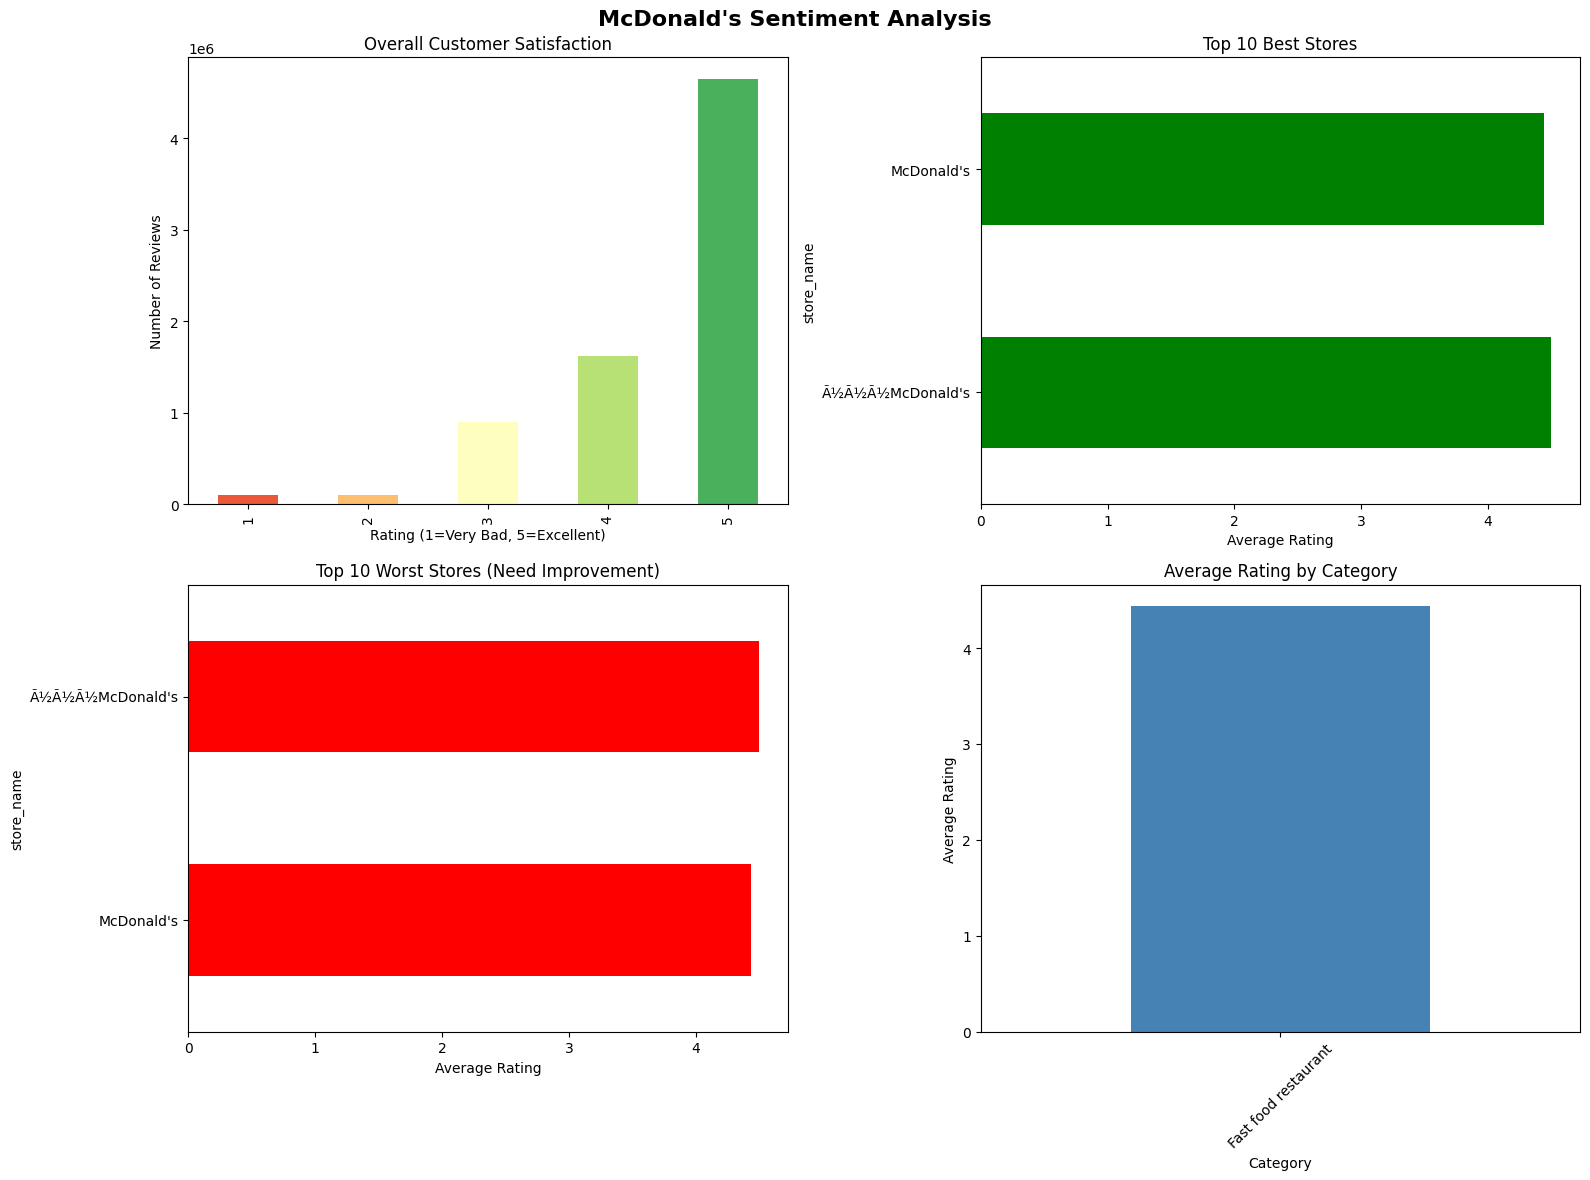

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overall satisfaction distribution
df_final['rating_x'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,0], color=sns.color_palette('RdYlGn', 5))
axes[0,0].set_title('Overall Customer Satisfaction')
axes[0,0].set_xlabel('Rating (1=Very Bad, 5=Excellent)')
axes[0,0].set_ylabel('Number of Reviews')

# 2. Satisfaction by store
df_final.groupby('store_name')['rating_x'].mean().nlargest(10).plot(
    kind='barh', ax=axes[0,1], color='green')
axes[0,1].set_title('Top 10 Best Stores')
axes[0,1].set_xlabel('Average Rating')

# 3. Worst stores (areas for improvement)
df_final.groupby('store_name')['rating_x'].mean().nsmallest(10).plot(
    kind='barh', ax=axes[1,0], color='red')
axes[1,0].set_title('Top 10 Worst Stores (Need Improvement)')
axes[1,0].set_xlabel('Average Rating')

# 4. Average Rating by Category
df_final.groupby('category')['rating_x'].mean().plot(
    kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Average Rating by Category')
axes[1,1].set_xlabel('Category')
axes[1,1].set_ylabel('Average Rating')
plt.xticks(rotation=45)

plt.suptitle("McDonald's Sentiment Analysis", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [83]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df_final['cleaned_review'].dropna())

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

print("Main Topics Customers Talk About:")
for idx, topic in enumerate(lda.components_):
    top_words = [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
    print(f"Topic {idx+1}: {', '.join(top_words)}")

Main Topics Customers Talk About:
Topic 1: coffee, price, value, place, attention, services, service, food, neutral, good
Topic 2: thanks, tasty, prices, service, wifi, google, neutral, good, attention, excellent
Topic 3: nice, place, great, fast, ok, order, mcdonalds, food, service, â½ã
Topic 4: shakes, neutral, good, excellent, alright, awful, yuck, yummy, love, terrible
Topic 5: yeah, neutral, good, excellent, meh, loved, awesome, bad, great, poor


In [84]:
store_report = df_final.groupby('store_name').agg(
    avg_rating=('rating_x', 'mean'),
    total_reviews=('rating_x', 'count'),
    positive=('rating_x', lambda x: (x >= 4).sum()),
    negative=('rating_x', lambda x: (x <= 2).sum())
).reset_index().sort_values('avg_rating', ascending=False)

print(store_report.head(10))

         store_name  avg_rating  total_reviews  positive  negative
1  Ã½Ã½Ã½McDonald's    4.498920          10645      8677      1012
0        McDonald's    4.437839        7371043   6263889    207648


In [85]:
store_report.to_excel('mcdonalds_final_report.xlsx', index=False)
print("Report saved!")

C:\Users\Enter Store\AppData\Local\Temp\ipykernel_27572\1946341171.py:1: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  store_report.to_excel('mcdonalds_final_report.xlsx', index=False)


Report saved!
